# Load data

In [30]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
import seaborn as sns
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

In [11]:

# soldata = pd.read_csv('https://dataverse.harvard.edu/api/access/datafile/3407241?format=original&gbrecs=true')
# had to rehost because dataverse isn't reliable
soldata = pd.read_csv(
    "https://github.com/whitead/dmol-book/raw/main/data/curated-solubility-dataset.csv"
)
soldata.head()

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,...,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934


# Data Exploration

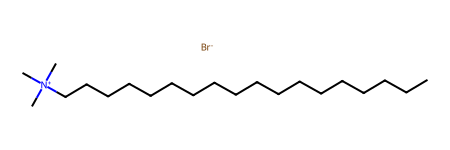

In [13]:
# plot one molecule
mol = Chem.MolFromInchi(soldata.InChI[0])
mol

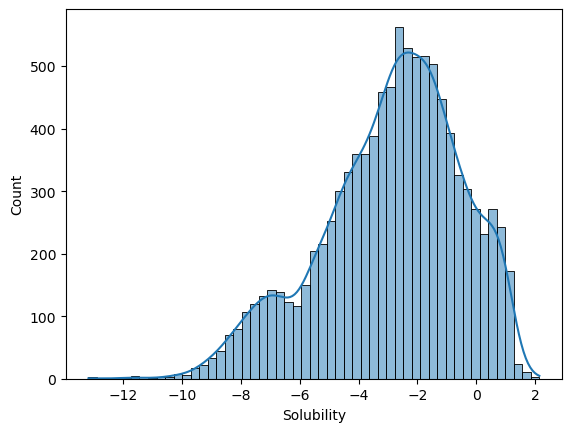

In [17]:
sns.histplot(soldata.Solubility, kde=True)
plt.show()

In [20]:
# get 3 lowest and 3 highest solubilities
soldata_sorted = soldata.sort_values("Solubility")
extremes = pd.concat([soldata_sorted[:3], soldata_sorted[-3:]])
extremes.head()

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
5528,B-2402,dechlorane plus,InChI=1S/C18H12Cl12/c19-9-10(20)15(25)7-3-4-8-...,UGQQAJOWXNCOPY-UHFFFAOYSA-N,ClC1=C(Cl)C2(Cl)C3CCC4C(CCC3C1(Cl)C2(Cl)Cl)C5(...,-13.171900,0.00000,1,G1,653.730,...,0.0,168.0,0.0,3.0,5.0,5.0,0.00,234.174100,1.619292e+00,782.127616
9875,H-94,Decachlorodiphenyl ether,InChI=1S/C12Cl10O/c13-1-3(15)7(19)11(8(20)4(1)...,CIPFDHFTBYJKQB-UHFFFAOYSA-N,ClC1=C(Cl)C(Cl)=C(OC2=C(Cl)C(Cl)=C(Cl)C(Cl)=C2...,-12.950000,0.00000,1,G1,514.661,...,2.0,124.0,2.0,0.0,0.0,2.0,9.23,180.634705,2.712767e+00,690.954533
7058,B-4424,"1,2,3,4,6,7,8,9-octachlorodibenzo-p-dioxin",InChI=1S/C12Cl8O2/c13-1-2(14)6(18)10-9(5(1)17)...,FOIBFBMSLDGNHL-UHFFFAOYSA-N,Clc1c(Cl)c(Cl)c2Oc3c(Cl)c(Cl)c(Cl)c(Cl)c3Oc2c1Cl,-12.060500,0.36475,2,G3,459.754,...,0.0,116.0,2.0,0.0,1.0,3.0,18.46,164.135886,2.320888e+00,697.841798
1948,A-3211,ammonium bromide,InChI=1S/BrH.H3N/h1H;1H3,SWLVFNYSXGMGBS-UHFFFAOYSA-N,[NH4+].[Br-],1.908300,0.00000,1,G1,97.943,...,0.0,16.0,0.0,0.0,0.0,0.0,36.50,24.016930,0.000000e+00,2.000000
1755,A-2889,bis(tetrakis(hydroxymethyl)phosphanium) sulfate,"InChI=1S/2C4H12O4P.H2O4S/c2*5-1-9(2-6,3-7)4-8;...",YIEDHPBKGZGLIK-UHFFFAOYSA-L,OC[P+](CO)(CO)CO.OC[P+](CO)(CO)CO.[O-][S]([O-]...,1.967513,0.00000,1,G1,406.283,...,8.0,144.0,0.0,0.0,0.0,0.0,242.10,134.460413,-2.730159e-07,293.052636


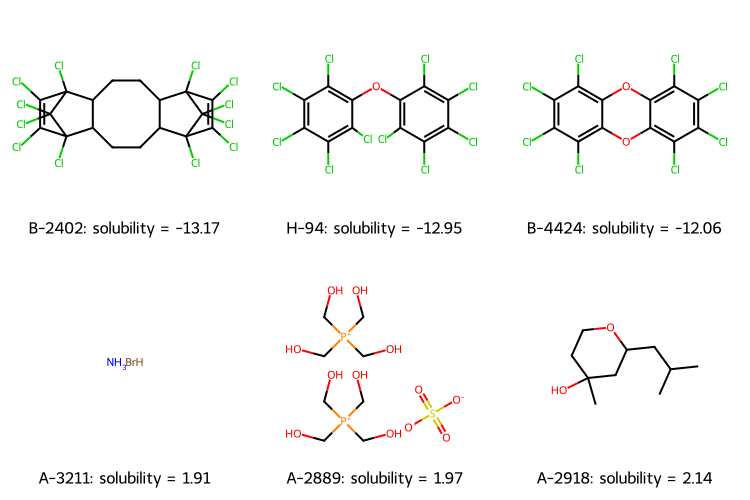

In [19]:
# We need to have a list of strings for legends
legend_text = [
    f"{x.ID}: solubility = {x.Solubility:.2f}" for x in extremes.itertuples()
]

# now plot them on a grid
extreme_mols = [Chem.MolFromInchi(inchi) for inchi in extremes.InChI]
Chem.Draw.MolsToGridImage(
    extreme_mols, molsPerRow=3, subImgSize=(250, 250), legends=legend_text
)

# Feature Correlation

In [22]:
list(soldata.columns)

['ID',
 'Name',
 'InChI',
 'InChIKey',
 'SMILES',
 'Solubility',
 'SD',
 'Ocurrences',
 'Group',
 'MolWt',
 'MolLogP',
 'MolMR',
 'HeavyAtomCount',
 'NumHAcceptors',
 'NumHDonors',
 'NumHeteroatoms',
 'NumRotatableBonds',
 'NumValenceElectrons',
 'NumAromaticRings',
 'NumSaturatedRings',
 'NumAliphaticRings',
 'RingCount',
 'TPSA',
 'LabuteASA',
 'BalabanJ',
 'BertzCT']

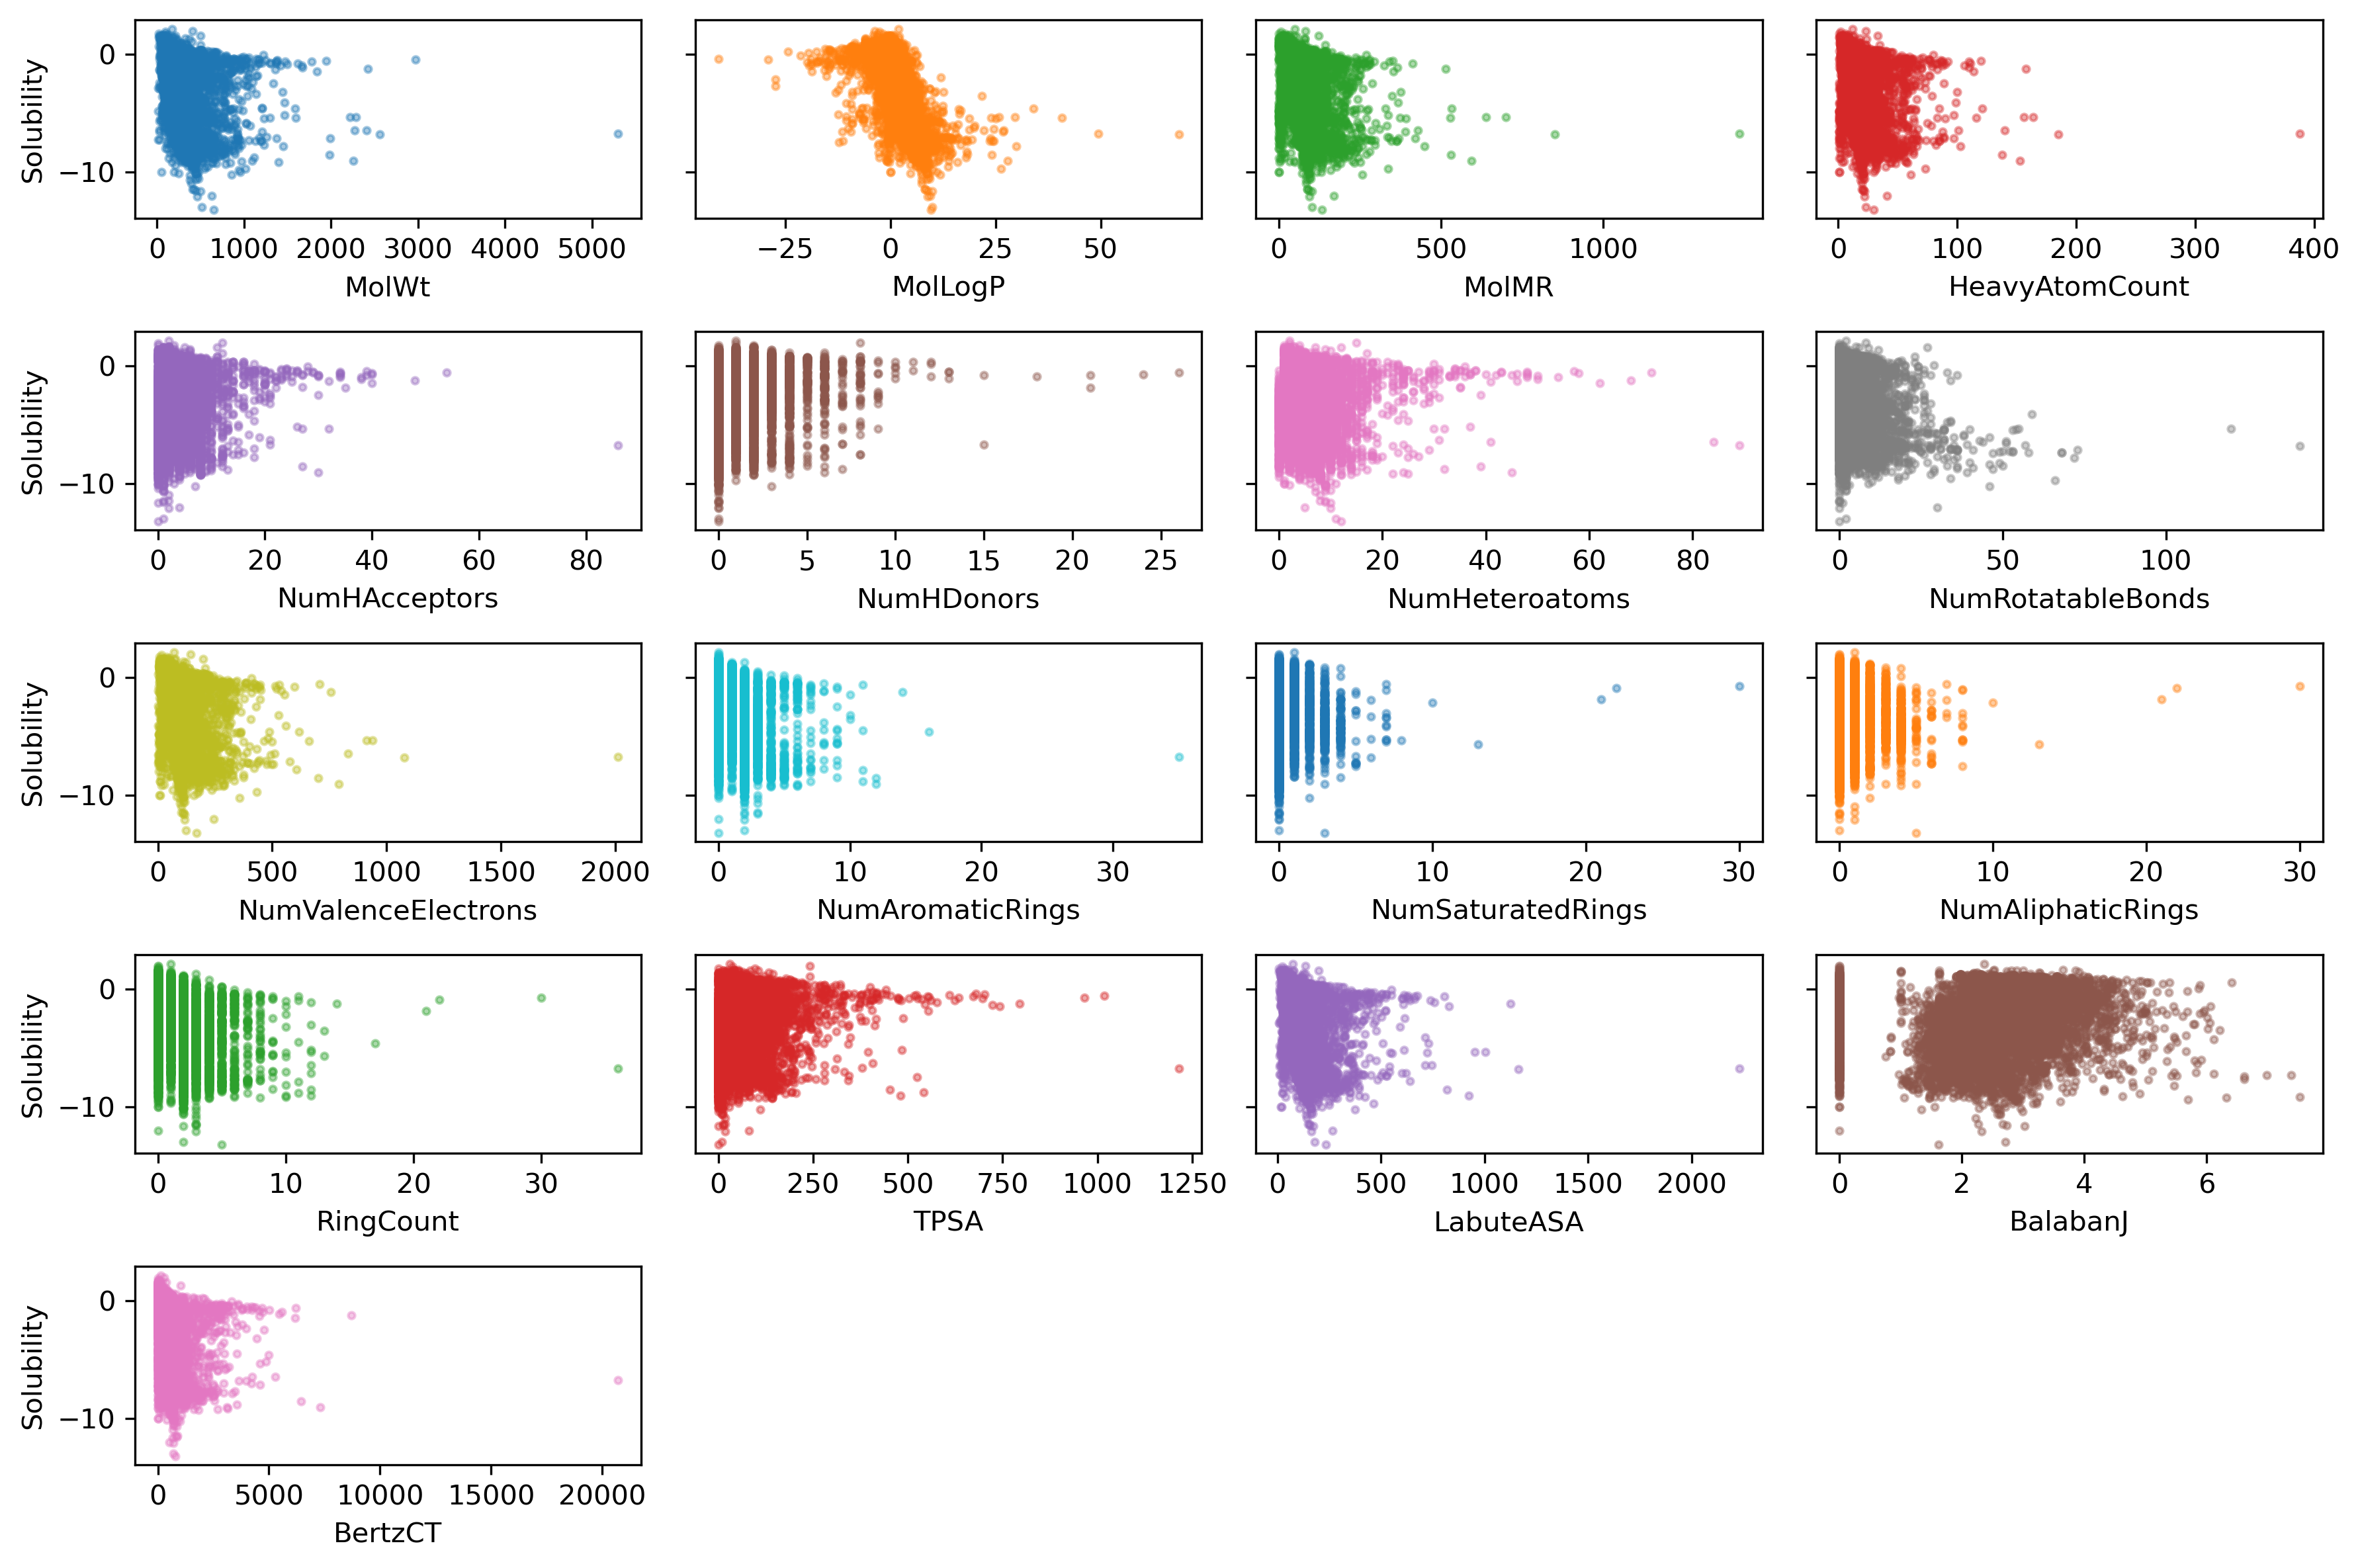

In [23]:
features_start_at = list(soldata.columns).index("MolWt")
feature_names = soldata.columns[features_start_at:]

fig, axs = plt.subplots(nrows=5, ncols=4, sharey=True, figsize=(12, 8), dpi=300)
axs = axs.flatten()  # so we don't have to slice by row and column
for i, n in enumerate(feature_names):
    ax = axs[i]
    ax.scatter(
        soldata[n], soldata.Solubility, s=6, alpha=0.4, color=f"C{i}"
    )  # add some color
    if i % 4 == 0:
        ax.set_ylabel("Solubility")
    ax.set_xlabel(n)
# hide empty subplots
for i in range(len(feature_names), len(axs)):
    fig.delaxes(axs[i])
plt.tight_layout()
plt.show()

# Linear Model

In [49]:
def linear_model(x, w, b):
    return jnp.dot(x, w) + b


# convert data into features, labels
features = soldata.loc[:, feature_names].values
labels = soldata.Solubility.values

feature_dim = features.shape[1]

# initialize our paramaters
w = np.random.normal(size=feature_dim)
b = 0.0


# define loss
def loss(y, labels):
    return jnp.mean((y - labels) ** 2)


# test it out
y = linear_model(features, w, b)
loss(y, labels)

Array(967693.56, dtype=float32)

In [32]:
# compute gradients
def loss_wrapper(w, b, data):
    features = data[0]
    labels = data[1]
    y = linear_model(features, w, b)
    return loss(y, labels)


loss_grad = jax.grad(loss_wrapper, (0, 1))

# test it out
loss_grad(w, b, (features, labels))

(Array([9.4014200e+05, 5.8491772e+03, 2.3424061e+05, 6.2655258e+04,
        1.3442192e+04, 3.3321855e+03, 1.9216250e+04, 1.3148349e+04,
        3.2818919e+05, 4.8551802e+03, 8.0626337e+02, 1.5055696e+03,
        6.3607407e+03, 2.2716892e+05, 3.9039288e+05, 4.0522227e+03,
        2.2980655e+06], dtype=float32),
 Array(2070.362, dtype=float32, weak_type=True))

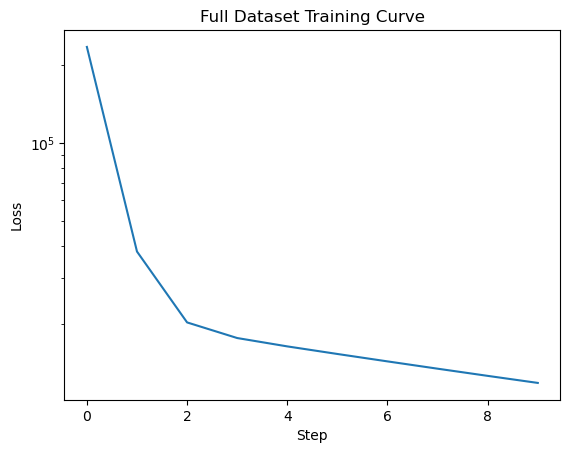

In [33]:
loss_progress = []
eta = 1e-6
data = (features, labels)
for i in range(10):
    grad = loss_grad(w, b, data)
    w -= eta * grad[0]
    b -= eta * grad[1]
    loss_progress.append(loss_wrapper(w, b, data))
plt.plot(loss_progress)

plt.xlabel("Step")
plt.yscale("log")
plt.ylabel("Loss")
plt.title("Full Dataset Training Curve")
plt.show()

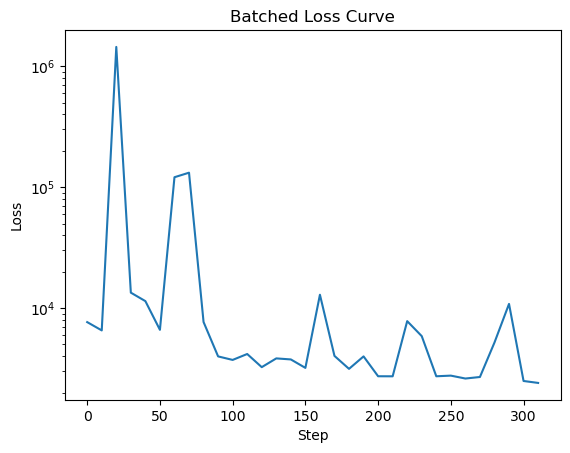

In [34]:
# initialize our paramaters
# to be fair to previous method
w = np.random.normal(size=feature_dim)
b = 0.0

loss_progress = []
eta = 1e-6
batch_size = 32
N = len(labels)  # number of data points
data = (features, labels)
# compute how much data fits nicely into a batch
# and drop extra data
new_N = len(labels) // batch_size * batch_size

# the -1 means that numpy will compute
# what that dimension should be
batched_features = features[:new_N].reshape((-1, batch_size, feature_dim))
batched_labels = labels[:new_N].reshape((-1, batch_size))
# to make it random, we'll iterate over the batches randomly
indices = np.arange(new_N // batch_size)
np.random.shuffle(indices)
for i in indices:
    # choose a random set of
    # indices to slice our data
    grad = loss_grad(w, b, (batched_features[i], batched_labels[i]))
    w -= eta * grad[0]
    b -= eta * grad[1]
    # we still compute loss on whole dataset, but not every step
    if i % 10 == 0:
        loss_progress.append(loss_wrapper(w, b, data))

plt.plot(np.arange(len(loss_progress)) * 10, loss_progress)
plt.xlabel("Step")
plt.yscale("log")
plt.ylabel("Loss")
plt.title("Batched Loss Curve")
plt.show()

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from jax.example_libraries import optimizers
import jax
import rdkit, rdkit.Chem, rdkit.Chem.Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
import dmol

ModuleNotFoundError: No module named 'dmol'

In [37]:
# soldata = pd.read_csv('https://dataverse.harvard.edu/api/access/datafile/3407241?format=original&gbrecs=true')
soldata = pd.read_csv(
    "https://github.com/whitead/dmol-book/raw/main/data/curated-solubility-dataset.csv"
)
features_start_at = list(soldata.columns).index("MolWt")
feature_names = soldata.columns[features_start_at:]

In [39]:
# Get 50 points and split into train/test
sample = soldata.sample(50, replace=False)
train = sample[:25]
test = sample[25:]

# standardize the features using only train
test[feature_names] -= train[feature_names].mean()
test[feature_names] /= train[feature_names].std()
train[feature_names] -= train[feature_names].mean()
train[feature_names] /= train[feature_names].std()

# convert from pandas dataframe to numpy arrays
x = train[feature_names].values
y = train["Solubility"].values
test_x = test[feature_names].values
test_y = test["Solubility"].values

/var/folders/2y/7k4lmpb96ls_d714_z5n2594bry8kf/T/ipykernel_15652/3815087055.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[feature_names] -= train[feature_names].mean()
/var/folders/2y/7k4lmpb96ls_d714_z5n2594bry8kf/T/ipykernel_15652/3815087055.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[feature_names] /= train[feature_names].std()
/var/folders/2y/7k4lmpb96ls_d714_z5n2594bry8kf/T/ipykernel_15652/3815087055.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

In [45]:
# compute gradients
def loss_wrapper(w, b, data):
    features = data[0]
    labels = data[1]
    y = linear_model(features, w, b)
    return loss(y, labels)


loss_grad = jax.grad(loss_wrapper, (0, 1))

# test it out
loss_grad(w, b, (features, labels))

(Array([ 4.1502275 ,  5.5019665 ,  4.173802  ,  3.6554039 ,  0.37253347,
         1.8715537 ,  2.3312495 ,  4.031696  ,  3.562937  ,  2.872416  ,
        -4.5033555 , -4.2365036 , -1.786111  ,  0.5864783 ,  3.9264245 ,
         2.9124892 ,  3.564588  ], dtype=float32),
 Array(6.2304683, dtype=float32, weak_type=True))

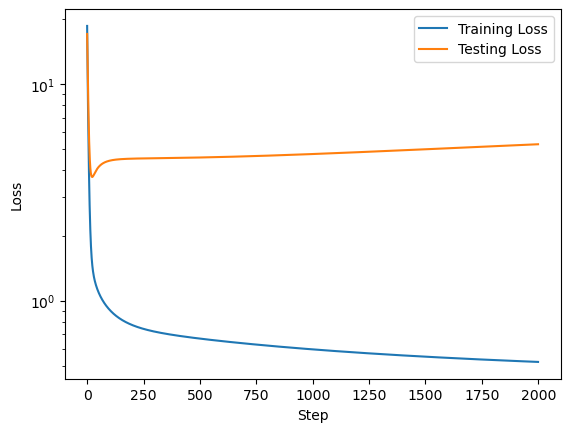

In [46]:
loss_progress = []
test_loss_progress = []
eta = 0.05
for i in range(2000):
    grad = loss_grad(w, b, x, y)
    w -= eta * grad[0]
    b -= eta * grad[1]
    loss_progress.append(loss(w, b, x, y))
    test_loss_progress.append(loss(w, b, test_x, test_y))
plt.plot(loss_progress, label="Training Loss")
plt.plot(test_loss_progress, label="Testing Loss")

plt.xlabel("Step")
plt.yscale("log")
plt.legend()
plt.ylabel("Loss")
plt.show()

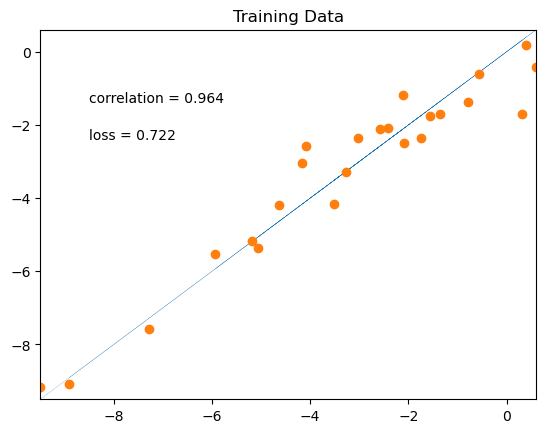

In [47]:
yhat = x @ w + b
plt.plot(y, y, ":", linewidth=0.2)
plt.plot(y, x @ w + b, "o")
plt.xlim(min(y), max(y))
plt.ylim(min(y), max(y))
plt.text(min(y) + 1, max(y) - 2, f"correlation = {np.corrcoef(y, yhat)[0,1]:.3f}")
plt.text(min(y) + 1, max(y) - 3, f"loss = {np.sqrt(np.mean((y - yhat)**2)):.3f}")
plt.title("Training Data")
plt.show()

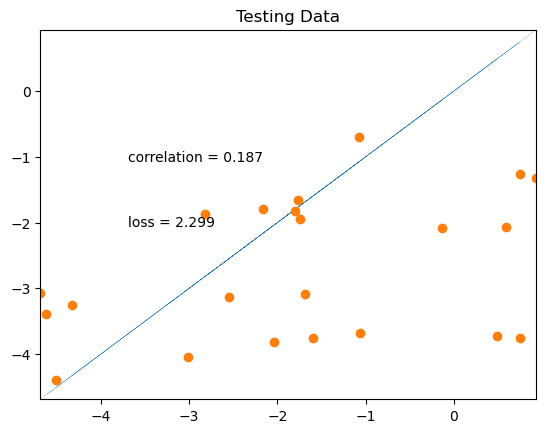

In [48]:
yhat = test_x @ w + b
plt.plot(test_y, test_y, ":", linewidth=0.2)
plt.plot(test_y, yhat, "o")
plt.xlim(min(test_y), max(test_y))
plt.ylim(min(test_y), max(test_y))
plt.text(
    min(test_y) + 1,
    max(test_y) - 2,
    f"correlation = {np.corrcoef(test_y, yhat)[0,1]:.3f}",
)
plt.text(
    min(test_y) + 1,
    max(test_y) - 3,
    f"loss = {np.sqrt(np.mean((test_y - yhat)**2)):.3f}",
)
plt.title("Testing Data")
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import rdkit, rdkit.Chem, rdkit.Chem.Draw
import numpy as np
import jax.numpy as jnp
import mordred, mordred.descriptors
import jax
import dmol

ImportError: cannot import name 'product' from 'numpy' (/Users/mehdimir/miniforge3/envs/jupyterbook/lib/python3.10/site-packages/numpy/__init__.py)

In [7]:
import sys, numpy as np
print(sys.executable)
print(np.__version__)

/Users/mehdimir/miniforge3/envs/jupyterbook/bin/python
2.2.5
